In [1]:
from pathlib import Path
import gzip
import json
from pprint import pprint
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
import numpy as np
from stable_platform_matchings.domain.instance import Instance
import seaborn as sns

In [2]:
sns.set_theme(context="paper", style="ticks")

In [3]:
root = Path("../results/exp_5")
all_jsons = list(root.rglob("*.json.gz"))
graph_data_filename = "../data/graph_0-14960_00_new.pickle"
instance = Instance.from_yaml(Path('../data/anon_14_day_instances/2020-08-27.yaml'))

In [48]:

# ============================================================
# SETTINGS
# ============================================================

# Example:
# all_jsons = sorted(Path("results/exp_3").glob("job_*/*.json.gz"))

LC_TO_USD = instance.lc_to_usd
TRUCK_FIXED_COST = instance.truck_fixed_cost

MAX_DEVIATION_POTENTIAL = 12

DEV_POT_BINS = np.linspace(2, 12, 7)
COST_BINS = np.linspace(65, 110, 7)

ZERO_TOL = 1e-8


# ============================================================
# PLOTTING STYLE
# ============================================================

def currency_formatter(x, pos):
    return f"${x:.0f}"


plt.rcParams.update({
    "font.size": 10,
    "axes.labelsize": 10,
    "axes.titlesize": 10,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.fontsize": 9,
})


# ============================================================
# LOAD PAIRED DATA
# ============================================================

data = []

for file in all_jsons:
    with gzip.open(file, "rt", encoding="utf-8") as f:
        aggregate_payload = json.load(f)

    job_id = aggregate_payload["job_id"]

    for payload in aggregate_payload["n_hist_sets"]:

        n_hist_sets = payload["metadata"]["n_hist_sets"]
        time_suboptimal = payload["summary"]["timestamps"][0]
        total_time = payload["summary"]["total_time"]
        aggregate = payload["metadata"]["aggregate"]

        instance_snapshot = payload["summary"]["instance_snapshot"]
        instance_id = instance_snapshot["instance_id"]

        epsilons = payload["sampled_inputs"]["epsilons"]
        het_costs = payload["sampled_inputs"]["het_costs"]
        intermediaries = instance_snapshot["intermediaries"]

        avg_epsilon = np.mean(list(epsilons.values()))

        total_quantity = sum(
            farmer["quantity"] for farmer in instance_snapshot["farmers"]
        )

        total_fruit_value = total_quantity * instance.fruit_price_per_ton

        result = payload["summary"]["platform_solve_result"]


        primary_result = result["primary_result"]

        max_int_result = result[
            "max_intermediary_welfare_result"
        ]

        max_farmer_result = result[
            "max_farmer_welfare_result"
        ]

        platform_profit = (
            max_int_result["platform_profit"]
        )

        max_intermediary_welfare = (
            max_int_result["intermediary_welfare"]
        )

        min_intermediary_welfare = (
            max_farmer_result["intermediary_welfare"]
        )

        min_farmer_welfare = (
            max_int_result["farmer_welfare"]
        )

        max_farmer_welfare = (
            max_farmer_result["farmer_welfare"]
        )

        row = {
            "job_id": job_id,
            "aggregate": aggregate,
            "n_hist_sets": n_hist_sets,
            "total_time": total_time,
            "time_suboptimal": time_suboptimal,
            "avg_epsilon": avg_epsilon,
            "platform_profit_pct": platform_profit / total_fruit_value,
            "min_intermediary_welfare_pct": min_intermediary_welfare / total_fruit_value,
            "max_intermediary_welfare_pct": max_intermediary_welfare / total_fruit_value,
            "min_farmer_welfare_pct": min_farmer_welfare / total_fruit_value,
            "max_farmer_welfare_pct": max_farmer_welfare / total_fruit_value
        }

        data.append(row)

df = pd.DataFrame(data)

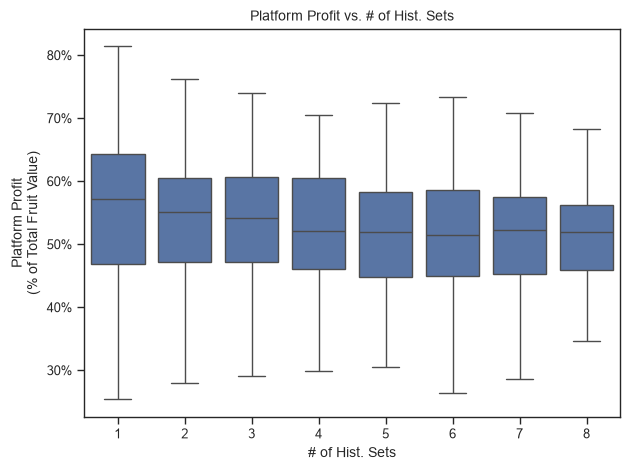

In [69]:
df_sweep = df[(df["aggregate"] == False) & (df["avg_epsilon"] == 1.0)]
ax = sns.boxplot(
    data=df_sweep,
    x="n_hist_sets",
    y="platform_profit_pct",
    showfliers=False
)

ax.yaxis.set_major_formatter(FuncFormatter(lambda y, _: f'{y * 100:.0f}%'))

plt.ylabel("Platform Profit\n(% of Total Fruit Value)")
plt.xlabel("# of Hist. Sets")
plt.title("Platform Profit vs. # of Hist. Sets")

plt.tight_layout()
plt.show()

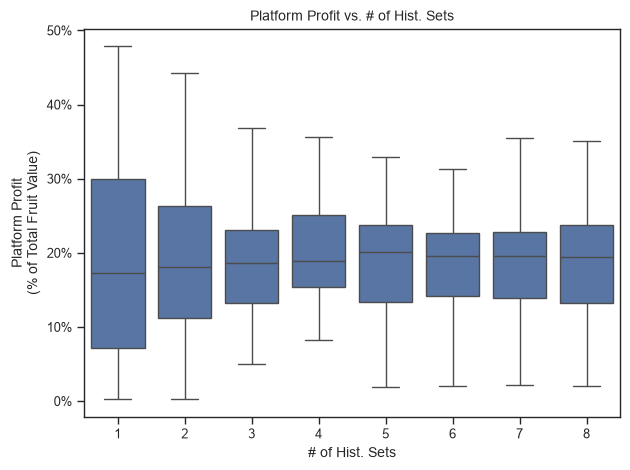

In [70]:
ax = sns.boxplot(
    data=df_sweep,
    x="n_hist_sets",
    y="max_intermediary_welfare_pct",
    showfliers=False
)

ax.yaxis.set_major_formatter(FuncFormatter(lambda y, _: f'{y * 100:.0f}%'))

plt.ylabel("Platform Profit\n(% of Total Fruit Value)")
plt.xlabel("# of Hist. Sets")
plt.title("Platform Profit vs. # of Hist. Sets")

plt.tight_layout()
plt.show()

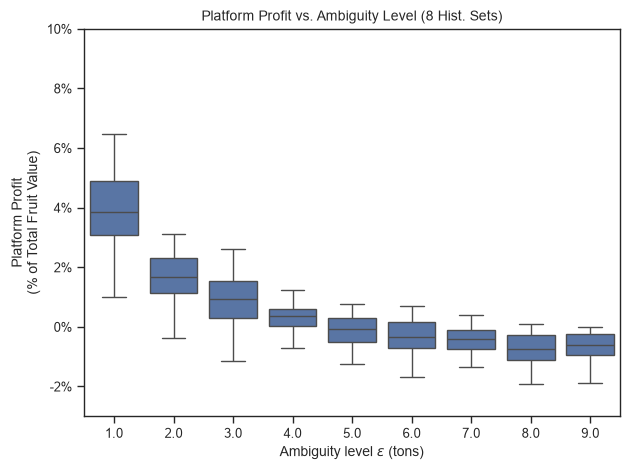

In [ ]:
ax = sns.boxplot(
    data=df_sweep,
    x="avg_epsilon",
    y="platform_profit_pct",
    showfliers=False
)

ax.yaxis.set_major_formatter(FuncFormatter(lambda y, _: f'{y * 100:.0f}%'))

plt.ylabel("Platform Profit\n(% of Total Fruit Value)")
plt.xlabel(r"Ambiguity level $\epsilon$ (tons)")
plt.title("Platform Profit vs. Ambiguity Level (8 Hist. Sets)")

plt.ylim(-0.03, 0.1)
plt.tight_layout()
plt.show()

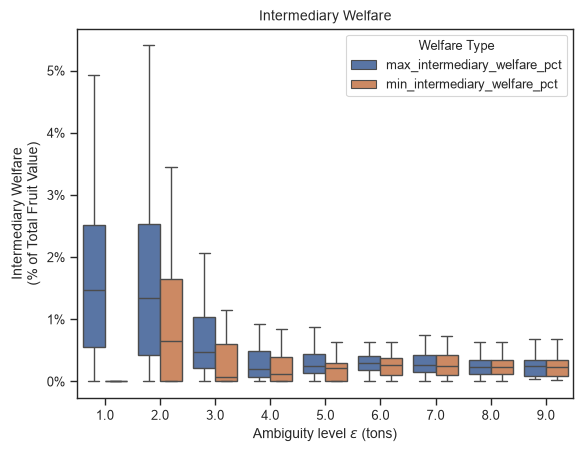

In [54]:
profit_data = df_sweep.melt(
    id_vars='avg_epsilon', 
    value_vars=['max_intermediary_welfare_pct', 'min_intermediary_welfare_pct'], 
    var_name='Welfare Type', 
    value_name='Welfare'
)

ax = sns.boxplot(
    data=profit_data,
    x="avg_epsilon",
    y="Welfare",
    hue="Welfare Type",
    showfliers=False
)

ax.yaxis.set_major_formatter(FuncFormatter(lambda y, _: f'{y * 100:.0f}%'))

plt.ylabel("Intermediary Welfare\n(% of Total Fruit Value)")
plt.xlabel(r"Ambiguity level $\epsilon$ (tons)")
plt.title("Intermediary Welfare")
plt.show()

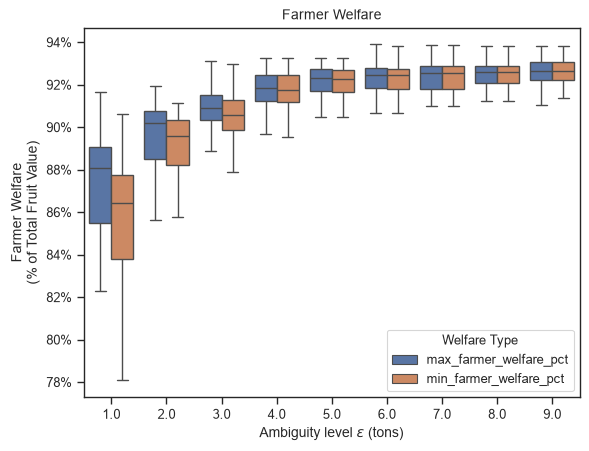

In [58]:
profit_data = df_sweep.melt(
    id_vars='avg_epsilon', 
    value_vars=['max_farmer_welfare_pct', 'min_farmer_welfare_pct'], 
    var_name='Welfare Type', 
    value_name='Welfare'
)

ax = sns.boxplot(
    data=profit_data,
    x="avg_epsilon",
    y="Welfare",
    hue="Welfare Type",
    showfliers=False
)

ax.yaxis.set_major_formatter(FuncFormatter(lambda y, _: f'{y * 100:.0f}%'))

plt.ylabel("Farmer Welfare\n(% of Total Fruit Value)")
plt.xlabel(r"Ambiguity level $\epsilon$ (tons)")
plt.title("Farmer Welfare")
plt.show()

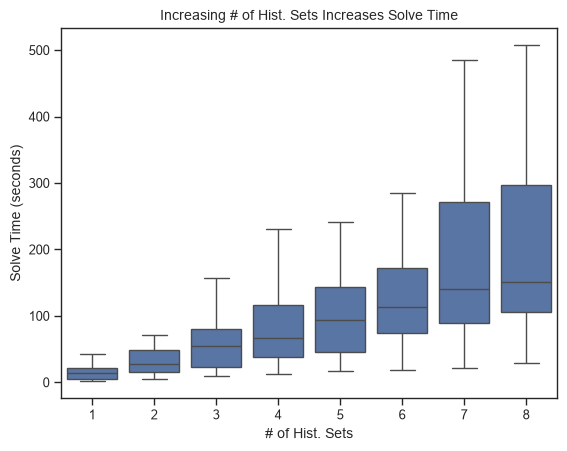

In [74]:
sns.boxplot(
    data=df_sweep,
    x="n_hist_sets",
    y="total_time",
    showfliers=False
)

plt.xlabel("# of Hist. Sets")
plt.ylabel("Solve Time (seconds)")
plt.title("Increasing # of Hist. Sets Increases Solve Time")

plt.show()

In [108]:
from numpy.polynomial import Polynomial

df_max = df_sweep.groupby("n_hist_sets")["total_time"].max().reset_index()

p_fit_max = Polynomial.fit(df_max['n_hist_sets'], df_max['total_time'], deg=1)

print("Coefficients:", p_fit_max.convert().coef) 

Coefficients: [ 8.39066224 87.85683154]


In [109]:
df_min = df_sweep.groupby("n_hist_sets")["total_time"].min().reset_index()

p_fit_min = Polynomial.fit(df_min['n_hist_sets'], df_min['total_time'], deg=1)

print("Coefficients:", p_fit_min.convert().coef) 

Coefficients: [-1.6972064   3.57749198]


In [110]:
df_mean = df_sweep.groupby("n_hist_sets")["total_time"].mean().reset_index()

p_fit_mean = Polynomial.fit(df_mean['n_hist_sets'], df_mean['total_time'], deg=1)

print("Coefficients:", p_fit_min.convert().coef) 

Coefficients: [-1.6972064   3.57749198]


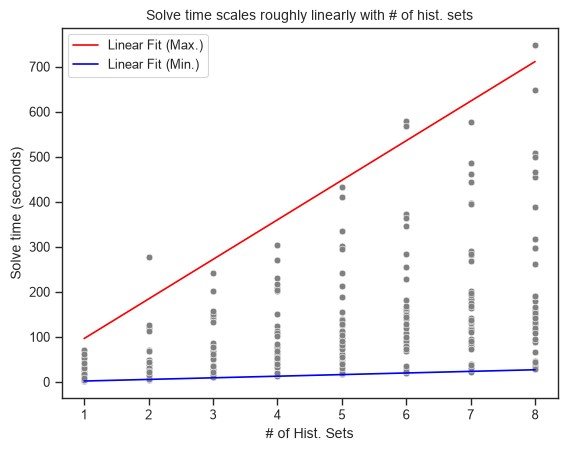

In [112]:
x_curve = np.linspace(df_sweep['n_hist_sets'].min(), df['n_hist_sets'].max())
y_max_curve = p_fit_max(x_curve)
y_min_curve = p_fit_min(x_curve)  # Evaluates the NumPy polynomial at those points

# Plotting
sns.scatterplot(df_sweep, x="n_hist_sets", y="total_time", color='gray')
plt.plot(x_curve, y_max_curve, color='red', label='Linear Fit (Max.)')
plt.plot(x_curve, y_min_curve, color='blue', label='Linear Fit (Min.)')

plt.xlabel("# of Hist. Sets")
plt.ylabel("Solve time (seconds)")
plt.title("Solve time scales roughly linearly with # of hist. sets")
plt.legend()
plt.show()